In [61]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [62]:
torch.cuda.is_available()
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 4050 Laptop GPU'

In [63]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import torch

In [64]:
file_path = r"P:\music-genre-classification\data\gtzan\genres_original\disco\disco.00006.wav"

y, sr = librosa.load(file_path, sr=22050)

print("Shape:", y.shape)
print("Sample Rate:", sr)
print("Duration:", len(y)/sr)

Shape: (661676,)
Sample Rate: 22050
Duration: 30.00798185941043


In [65]:
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("Mel shape:", mel_spec_db.shape)

Mel shape: (128, 1293)


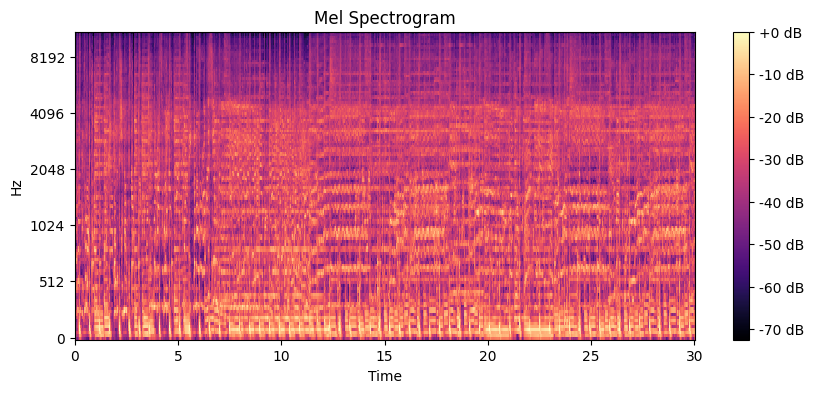

In [66]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

<h1>Phase 2 — Dataset Pipeline

Audio (.wav) -->
Waveform (1D signal) --> 
Mel Spectrogram (2D feature) --> 
Fixed Size (padding/truncation) --> 
Tensor (PyTorch format) --> 
Dataset --> 
DataLoader (batching) --> 
CNN Model --> 
Loss + Optimizer --> 
Training Loop -->
Predicted Genre

Waveform shape: (661794,)
Sample rate: 22050
STFT shape: (1025, 1293)


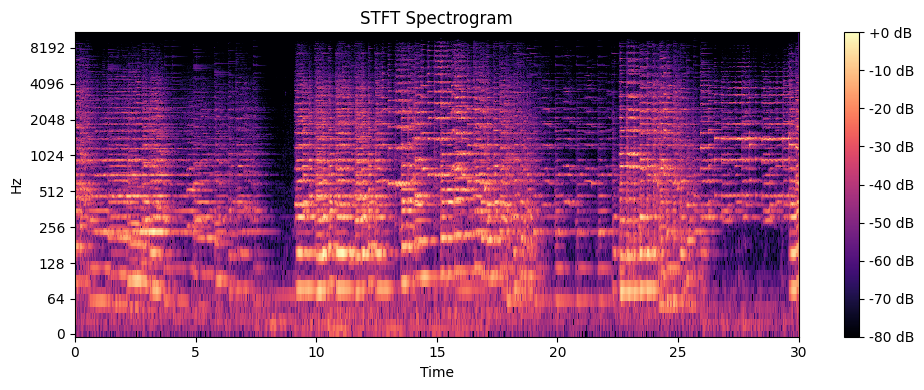

In [71]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# 1. Load audio
file_path = r"P:\music-genre-classification\data\gtzan\genres_original\classical\classical.00007.wav"

y, sr = librosa.load(file_path, sr=22050)

print("Waveform shape:", y.shape)
print("Sample rate:", sr)

# 2. Apply STFT
stft = librosa.stft(
    y,
    n_fft=2048,       # window size
    hop_length=512    # step size
)

print("STFT shape:", stft.shape)

# 3. Convert to magnitude
stft_magnitude = np.abs(stft)

# 4. Convert to decibel scale (log scale)
stft_db = librosa.amplitude_to_db(stft_magnitude, ref=np.max)

# 5. Visualize
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    stft_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='log'
)
plt.colorbar(format='%+2.0f dB')
plt.title('STFT Spectrogram')
plt.tight_layout()
plt.show()

In [67]:
import os

DATA_PATH = r"P:\music-genre-classification\data\gtzan\genres_original"

genres = os.listdir(DATA_PATH)

file_paths = []
labels = []

for label, genre in enumerate(genres):
    genre_path = os.path.join(DATA_PATH, genre)
    
    for file in os.listdir(genre_path):
        file_paths.append(os.path.join(genre_path, file))
        labels.append(label)

print("Total files:", len(file_paths))
print("Example:", file_paths[0], labels[0])

Total files: 1000
Example: P:\music-genre-classification\data\gtzan\genres_original\blues\blues.00000.wav 0


Precompute Spectrogram Dataset

In [73]:
import os
import librosa
import numpy as np

DATA_PATH = r"P:\music-genre-classification\data\gtzan\genres_original"
SAVE_PATH = r"P:\music-genre-classification\data\gtzan\genres_original\processed"

os.makedirs(SAVE_PATH, exist_ok=True)

MAX_LEN = 1300
SR = 22050

def pad_or_truncate(mel, max_len=MAX_LEN):
    if mel.shape[1] < max_len:
        pad_width = max_len - mel.shape[1]
        mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel = mel[:, :max_len]
    return mel

features = []
labels = []

genres = sorted(os.listdir(DATA_PATH))

for label, genre in enumerate(genres):
    genre_path = os.path.join(DATA_PATH, genre)
    
    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)

        try:
            y, sr = librosa.load(file_path, sr=SR)

            mel = librosa.feature.melspectrogram(
                y=y, sr=sr,
                n_fft=2048,
                hop_length=512,
                n_mels=128
            )

            mel = librosa.power_to_db(mel, ref=np.max)
            mel = pad_or_truncate(mel)

            # normalize
            mel = (mel - mel.mean()) / (mel.std() + 1e-6)

            features.append(mel)
            labels.append(label)

        except:
            print("Skipped:", file_path)
            continue

# Convert to arrays
features = np.array(features)
labels = np.array(labels)

print("Final shape:", features.shape)

# Save
np.save(os.path.join(SAVE_PATH, "X.npy"), features)
np.save(os.path.join(SAVE_PATH, "y.npy"), labels)

C:\Users\soham\AppData\Local\Temp\ipykernel_259540\1176071794.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SR)


Skipped: P:\music-genre-classification\data\gtzan\genres_original\jazz\jazz.00054.wav
Final shape: (999, 128, 1300)


Build Simple Dataset

In [74]:
import torch
from torch.utils.data import Dataset

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

Load Dataset

In [77]:
X = np.load(r"P:\music-genre-classification\notebooks\data\processed\X.npy")
y = np.load(r"P:\music-genre-classification\notebooks\data\processed\y.npy")

dataset = NumpyDataset(X, y)

print(len(dataset))

FileNotFoundError: [Errno 2] No such file or directory: 'P:\\music-genre-classification\\notebooks\\data\\processed\\X.npy'

In [ ]:
import os


SAVE_PATH = "data/processed"
os.makedirs(SAVE_PATH, exist_ok=True)

print("Saving to:", os.path.abspath(SAVE_PATH))

Saving to: p:\music-genre-classification\notebooks\data\processed


In [82]:
import librosa
import numpy as np

DATA_PATH = r"P:\music-genre-classification\data\gtzan\genres_original"

features = []
labels = []

genres = sorted(os.listdir(DATA_PATH))

count = 0

for label, genre in enumerate(genres):
    genre_path = os.path.join(DATA_PATH, genre)

    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)

        try:
            y, sr = librosa.load(file_path, sr=22050)

            mel = librosa.feature.melspectrogram(
                y=y, sr=sr,
                n_fft=2048,
                hop_length=512,
                n_mels=128
            )

            mel = librosa.power_to_db(mel, ref=np.max)

            features.append(mel)
            labels.append(label)

            count += 1
            if count >= 20:   # 🔥 only 20 samples
                break

        except Exception as e:
            print("Skipped:", file_path)

    if count >= 20:
        break

print("Collected:", len(features))

Collected: 20


In [83]:
features = np.array(features)
labels = np.array(labels)

print("Shape:", features.shape)

np.save("data/processed/X.npy", features)
np.save("data/processed/y.npy", labels)

Shape: (20, 128, 1293)


In [84]:
import os
print(os.listdir("data/processed"))

['X.npy', 'y.npy']


In [85]:
X = np.load("data/processed/X.npy")
y = np.load("data/processed/y.npy")

print(X.shape, y.shape)

(20, 128, 1293) (20,)


In [ ]:
import os
import librosa
import numpy as np

DATA_PATH = "data/gtzan/genres_original"
SAVE_PATH = "data/processed"

os.makedirs(SAVE_PATH, exist_ok=True)

SR = 22050
MAX_LEN = 1300

def pad_or_truncate(mel, max_len=MAX_LEN):
    if mel.shape[1] < max_len:
        pad_width = max_len - mel.shape[1]
        mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel = mel[:, :max_len]
    return mel

features = []
labels = []

genres = sorted(os.listdir(DATA_PATH))

total = 0
skipped = 0

for label, genre in enumerate(genres):
    genre_path = os.path.join(DATA_PATH, genre)

    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)

        try:
            y, sr = librosa.load(file_path, sr=SR)

            mel = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_fft=2048,
                hop_length=512,
                n_mels=128
            )

            mel = librosa.power_to_db(mel, ref=np.max)

            # 🔥 FIX SHAPE HERE
            mel = pad_or_truncate(mel)

            # 🔥 NORMALIZE
            mel = (mel - mel.mean()) / (mel.std() + 1e-6)

            features.append(mel)
            labels.append(label)

            total += 1

            if total % 100 == 0:
                print(f"Processed: {total}")

        except Exception as e:
            skipped += 1
            continue

print("Done!")
print("Total processed:", total)
print("Skipped:", skipped)

features = np.array(features)
labels = np.array(labels)

print("Final shape:", features.shape)

# SAVE
np.save(os.path.join(SAVE_PATH, "X.npy"), features)
np.save(os.path.join(SAVE_PATH, "y.npy"), labels)

<h1>FULL DATASET PREPROCESSING

<h3>Complete Script

In [1]:
import os
import librosa
import numpy as np

DATA_PATH = r"P:\music-genre-classification\data\gtzan\genres_original"
SAVE_PATH = r"P:\music-genre-classification\data\processed"

os.makedirs(SAVE_PATH, exist_ok=True)

SR = 22050
MAX_LEN = 1300

def pad_or_truncate(mel, max_len=MAX_LEN):
    if mel.shape[1] < max_len:
        pad_width = max_len - mel.shape[1]
        mel = np.pad(mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel = mel[:, :max_len]
    return mel

features = []
labels = []

genres = sorted(os.listdir(DATA_PATH))

total = 0
skipped = 0

for label, genre in enumerate(genres):
    genre_path = os.path.join(DATA_PATH, genre)

    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)

        try:
            y, sr = librosa.load(file_path, sr=SR)

            mel = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_fft=2048,
                hop_length=512,
                n_mels=128
            )

            mel = librosa.power_to_db(mel, ref=np.max)

            # 🔥 FIX SHAPE HERE
            mel = pad_or_truncate(mel)

            # 🔥 NORMALIZE
            mel = (mel - mel.mean()) / (mel.std() + 1e-6)

            features.append(mel)
            labels.append(label)

            total += 1

            if total % 100 == 0:
                print(f"Processed: {total}")

        except Exception as e:
            skipped += 1
            continue

print("Done!")
print("Total processed:", total)
print("Skipped:", skipped)

features = np.array(features)
labels = np.array(labels)

print("Final shape:", features.shape)

# SAVE
np.save(os.path.join(SAVE_PATH, "X.npy"), features)
np.save(os.path.join(SAVE_PATH, "y.npy"), labels)

Processed: 100
Processed: 200
Processed: 300
Processed: 400
Processed: 500


C:\Users\soham\AppData\Local\Temp\ipykernel_287672\1935779103.py:36: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SR)
p:\music-genre-classification\.venv\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processed: 600
Processed: 700
Processed: 800
Processed: 900
Done!
Total processed: 999
Skipped: 1
Final shape: (999, 128, 1300)


<h2>Verify Saved Files

In [3]:
import os
print(os.listdir(r"P:\music-genre-classification\data\processed"))

['X.npy', 'y.npy']


In [5]:
X = np.load(r"P:\music-genre-classification\data\processed\X.npy")
y = np.load(r"P:\music-genre-classification\data\processed\y.npy")

print("X:", X.shape)
print("y:", y.shape)

X: (999, 128, 1300)
y: (999,)


<h3>Dataset Class

In [6]:
import torch
from torch.utils.data import Dataset

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

<h3>rain/Val Split + Loader

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_dataset = NumpyDataset(X_train, y_train)
val_dataset = NumpyDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

x, y = next(iter(train_loader))
print("Batch:", x.shape)

Batch: torch.Size([16, 1, 128, 1300])


<h2>CNN MODEL

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AudioCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AudioCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2)

        # 🔥 adaptive pooling removes shape headache
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

<h2>Training Setup

In [9]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AudioCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

<h2>Training + Validation Functions

In [10]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total


def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

<h3>TRAIN LOOP

In [12]:
EPOCHS = 15

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

Epoch 1/15
Train Loss: 1.1716 | Train Acc: 0.5732
Val Loss:   1.1721 | Val Acc:   0.5750
--------------------------------------------------
Epoch 2/15
Train Loss: 1.0931 | Train Acc: 0.5895
Val Loss:   1.1950 | Val Acc:   0.5300
--------------------------------------------------
Epoch 3/15
Train Loss: 1.0661 | Train Acc: 0.6058
Val Loss:   1.1058 | Val Acc:   0.6250
--------------------------------------------------
Epoch 4/15
Train Loss: 0.9848 | Train Acc: 0.6258
Val Loss:   1.1077 | Val Acc:   0.5800
--------------------------------------------------
Epoch 5/15
Train Loss: 0.9949 | Train Acc: 0.6208
Val Loss:   1.0826 | Val Acc:   0.6400
--------------------------------------------------
Epoch 6/15
Train Loss: 0.9199 | Train Acc: 0.6496
Val Loss:   0.9986 | Val Acc:   0.6650
--------------------------------------------------
Epoch 7/15
Train Loss: 0.9257 | Train Acc: 0.6633
Val Loss:   1.0276 | Val Acc:   0.6150
--------------------------------------------------
Epoch 8/15
Train Los

In [13]:
torch.save(model.state_dict(), "cnn_model.pth")

In [20]:
X = np.load(r"P:\music-genre-classification\data\processed\X.npy")
y = np.load(r"P:\music-genre-classification\data\processed\y.npy")

print("X:", X.shape)
print("y:", y.shape)

X: (999, 128, 1300)
y: (999,)


<h1> RestNet

<h3>DataSet

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [22]:
batch_x, batch_y = next(iter(train_loader))
print(batch_x.shape)

torch.Size([16, 3, 224, 224])


<h1> Model Set Up

In [30]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)

for param in model.parameters():
    param.requires_grad = False
    
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = model.to(device)

<h2> training

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0003)

In [32]:
import torch
from torch.utils.data import Dataset

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

<h3> train

In [35]:
import os

# 🔥 create weights folder if not exists
os.makedirs("weights", exist_ok=True)

best_val_acc = 0.0

best_val_acc = 0.0

EPOCHS = 6

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

    # 🔥 SAVE ONLY BEST MODEL
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(model.state_dict(), "weights/resnet_model.pth")

        print(f"✅ Saved BEST model at epoch {epoch+1} (Val Acc: {val_acc:.4f})")

Epoch 1/6
Train Loss: 0.0157 | Train Acc: 0.9987
Val Loss:   0.7999 | Val Acc:   0.7700
--------------------------------------------------
✅ Saved BEST model at epoch 1 (Val Acc: 0.7700)
Epoch 2/6
Train Loss: 0.0095 | Train Acc: 0.9975
Val Loss:   0.7530 | Val Acc:   0.7650
--------------------------------------------------
Epoch 3/6
Train Loss: 0.0095 | Train Acc: 0.9975
Val Loss:   0.7718 | Val Acc:   0.7700
--------------------------------------------------
Epoch 4/6
Train Loss: 0.0067 | Train Acc: 0.9987
Val Loss:   0.8050 | Val Acc:   0.7750
--------------------------------------------------
✅ Saved BEST model at epoch 4 (Val Acc: 0.7750)
Epoch 5/6
Train Loss: 0.0059 | Train Acc: 0.9987
Val Loss:   0.8042 | Val Acc:   0.7650
--------------------------------------------------
Epoch 6/6
Train Loss: 0.0058 | Train Acc: 0.9987
Val Loss:   0.8662 | Val Acc:   0.7700
--------------------------------------------------


In [36]:
import os
print(os.listdir("weights"))


['resnet_model.pth']
